In [225]:
# Importing packages
import pyspark.sql.functions as F
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Nice to have in notebooks
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

def parse_dnr(d):
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


In [226]:
# Paths assuming notebook is in src/phasebalance
sm_path = "../data/smartmeter_15min_all_from_devices_20251101_20251103.parquet"
jn_path = "../data/janitza_15min_all_20251101_1200_20251103_1200.parquet"

df_sm = pd.read_parquet(sm_path)
df_jn = pd.read_parquet(jn_path)

# List of substations / dnr_str values you want to exclude
exclude_dnr = ["D0006", "D1133","D1508","D1160", "D1159", "D0841", "D1329", "D1340","D1554","D0604","D0029","D1390","D1021","D1357","D0707"]  # add more here later

df_jn = df_jn[~df_jn["dnr_str"].isin(exclude_dnr)].copy()


print("Smartmeter shape:", df_sm.shape)
print("Janitza shape   :", df_jn.shape)
print("Smartmeter cols:", df_sm.columns.tolist())
print("Janitza cols   :", df_jn.columns.tolist())


Smartmeter shape: (16598, 8)
Janitza shape   : (10177, 6)
Smartmeter cols: ['substation_id', 'ts', 'I_a', 'I_b', 'I_c', 'I_total', 'n_mps', 'per_completed']
Janitza cols   : ['ts', 'I_a', 'I_b', 'I_c', 'I_total', 'dnr_str']


In [227]:
# 1) Parse dnr_str -> substation_id on the Janitza side
df_jn["substation_id"] = df_jn["dnr_str"].map(parse_dnr)

# 2) Ensure timestamps are datetime
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_jn["ts"] = pd.to_datetime(df_jn["ts"])

# 3) Sort for sanity
df_sm = df_sm.sort_values(["substation_id", "ts"])
df_jn = df_jn.sort_values(["substation_id", "ts"])

print("Example smartmeter substations:", df_sm["substation_id"].dropna().unique()[:10])
print("Example Janitza substations  :", df_jn["substation_id"].dropna().unique()[:10])


Example smartmeter substations: [  6  29  55  74  76 173 176 202 246 263]
Example Janitza substations  : [ 55  74  76 173 176 202 246 263 383 411]


In [228]:
# Force both ts columns to be UTC -> then drop timezone (naive but aligned)
df_sm["ts"] = pd.to_datetime(df_sm["ts"], utc=True).dt.tz_localize(None)
df_jn["ts"] = pd.to_datetime(df_jn["ts"], utc=True).dt.tz_localize(None)

print("df_sm ts dtype:", df_sm["ts"].dtype)
print("df_jn ts dtype:", df_jn["ts"].dtype)



# Merge on substation_id + ts (inner join = only overlapping timestamps)
merged = df_sm.merge(
    df_jn,
    on=["substation_id", "ts"],
    how="inner",
    suffixes=("_sm", "_jn"),
)

print("Merged shape:", merged.shape)
merged[["substation_id", "ts"]].head()

for col in ["I_a", "I_b", "I_c", "I_total"]:
    merged[f"{col}_diff"] = merged[f"{col}_sm"] - merged[f"{col}_jn"]

merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()


df_sm ts dtype: datetime64[ns]
df_jn ts dtype: datetime64[ns]
Merged shape: (9023, 13)


,I_a_diff,I_b_diff,I_c_diff,I_total_diff
count,9023.000000,9023.000000,9023.000000,9023.000000
mean,83.653506,-53.111148,-47.496433,-16.954075
std,176.896667,190.857422,181.299017,475.711875
min,-690.244726,-1586.371496,-1376.864009,-3519.917121
25%,-7.197606,-107.621730,-98.085785,-135.178888
50%,59.232183,-41.623050,-29.743662,-19.372534
75%,172.294244,-0.396370,0.571052,37.270509
max,917.774286,598.332327,627.881385,1837.552859


Rows for substation 1394 : 192


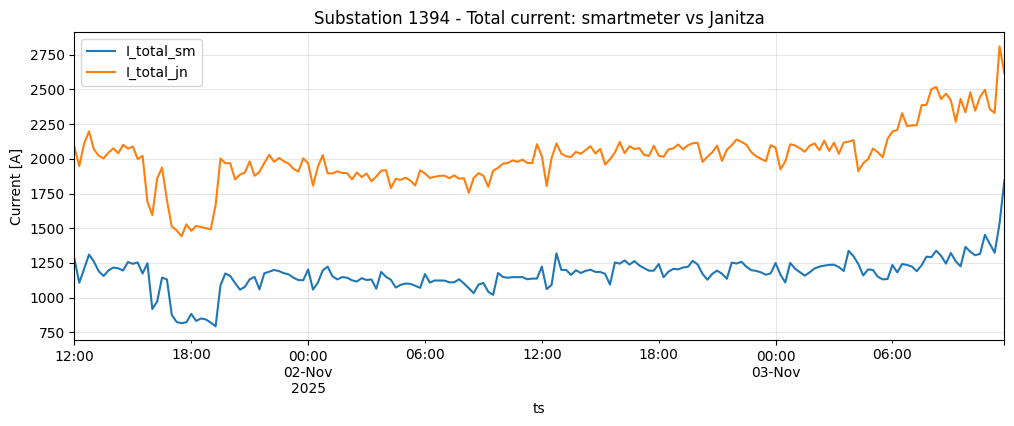

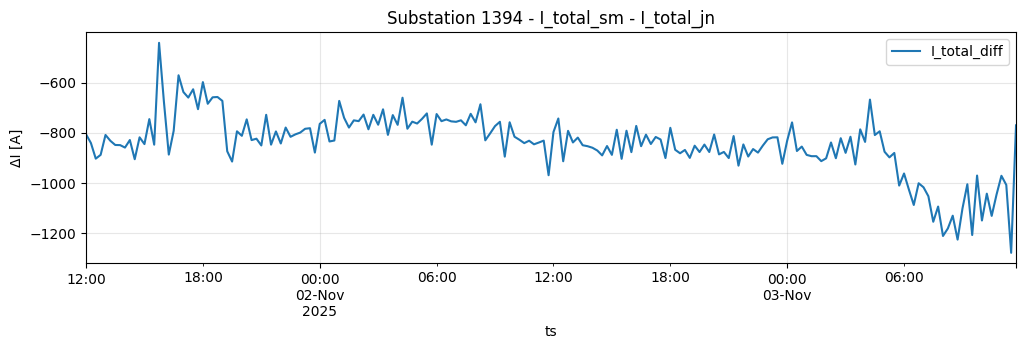

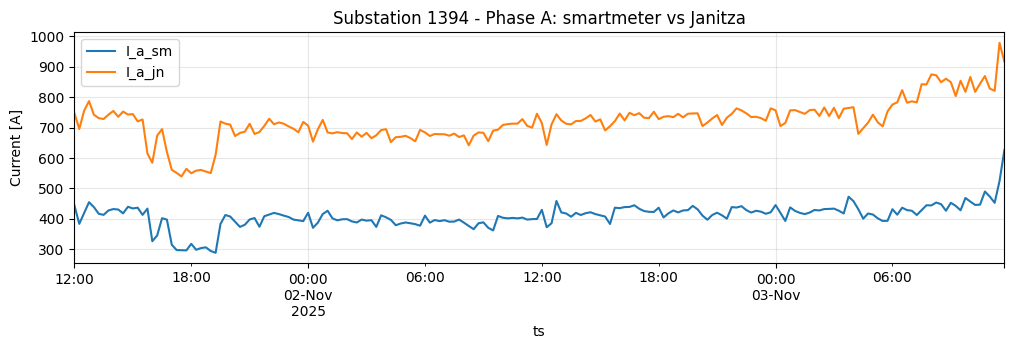

In [238]:
sub = 1394  # change this to whatever you want

sub_df = (
    merged[merged["substation_id"] == sub]
    .set_index("ts")
    .sort_index()
)

print("Rows for substation", sub, ":", sub_df.shape[0])
sub_df[["I_total_sm", "I_total_jn", "I_total_diff"]].head()

ax = sub_df[["I_total_sm", "I_total_jn"]].plot(
    figsize=(12, 4),
    title=f"Substation {sub} - Total current: smartmeter vs Janitza",
)
ax.set_ylabel("Current [A]")
ax.grid(True, alpha=0.3)
plt.show()

ax2 = sub_df[["I_total_diff"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - I_total_sm - I_total_jn",
)
ax2.set_ylabel("ΔI [A]")
ax2.grid(True, alpha=0.3)
plt.show()

ax3 = sub_df[["I_a_sm", "I_a_jn"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - Phase A: smartmeter vs Janitza",
)
ax3.set_ylabel("Current [A]")
ax3.grid(True, alpha=0.3)
plt.show()


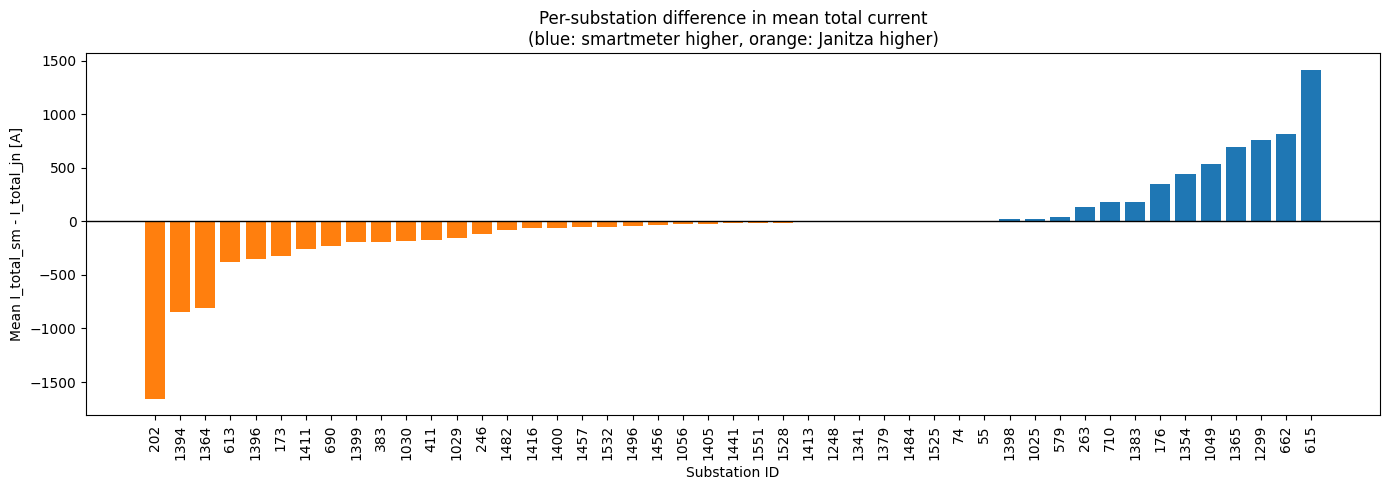

In [230]:

sub_stats = (
    merged
    .groupby("substation_id")
    .agg(
        mean_I_total_sm = ("I_total_sm", "mean"),
        mean_I_total_jn = ("I_total_jn", "mean"),
        mean_diff       = ("I_total_diff", "mean"),      # same as above two minus each other
    )
)

# (Optional) sort by difference so the bar chart is easier to read
sub_stats = sub_stats.sort_values("mean_diff")

# 2) Prepare data for plotting
x = np.arange(len(sub_stats))
y = sub_stats["mean_diff"].values
subs = sub_stats.index.astype(int)

# Color: blue if smartmeter > Janitza, orange otherwise
colors = ["tab:blue" if val > 0 else "tab:orange" for val in y]

# 3) Plot
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, y, color=colors)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean I_total_sm - I_total_jn [A]")
ax.set_title("Per-substation difference in mean total current\n"
             "(blue: smartmeter higher, orange: Janitza higher)")

plt.tight_layout()
plt.show()


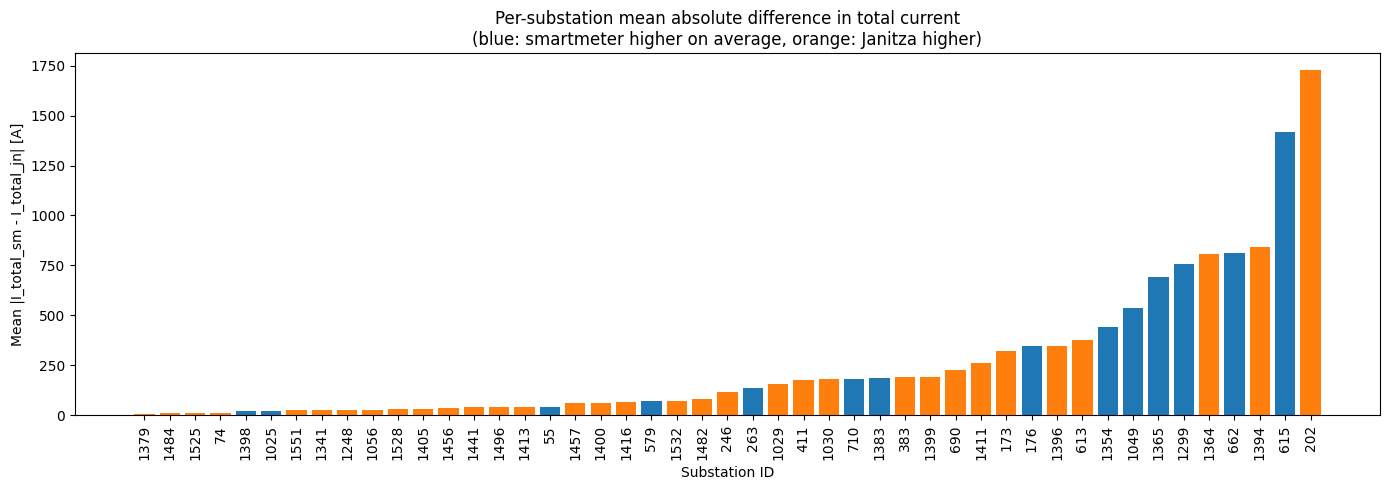

In [231]:
sub_stats["mean_abs_diff"] = (
    merged
    .groupby("substation_id")["I_total_diff"]
    .apply(lambda s: s.abs().mean())
)

sub_stats = sub_stats.sort_values("mean_abs_diff")

x = np.arange(len(sub_stats))
height = sub_stats["mean_abs_diff"].values
sign   = sub_stats["mean_diff"].values  # from previous aggregation
colors = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs   = sub_stats.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [A]")
ax.set_title("Per-substation mean absolute difference in total current\n"
             "(blue: smartmeter higher on average, orange: Janitza higher)")
plt.tight_layout()
plt.show()


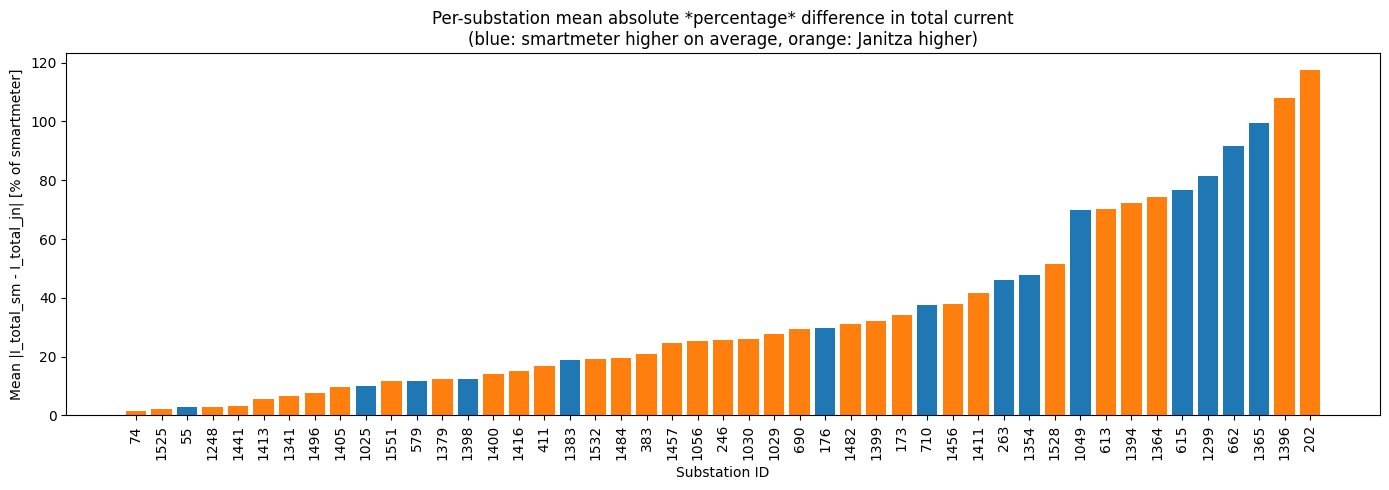

In [232]:
# Mean absolute *percentage* difference per substation (relative to smartmeter)

# Per-sample absolute percentage diff (NaN if smartmeter current is 0)
merged["I_total_abs_pct_diff"] = (
    100 * merged["I_total_diff"].abs() / merged["I_total_sm"].replace(0, np.nan)
)

# Aggregate per substation
sub_stats["mean_abs_pct_diff"] = (
    merged
    .groupby("substation_id")["I_total_abs_pct_diff"]
    .mean()
)

# Sort for nicer plotting
sub_stats_pct = sub_stats.sort_values("mean_abs_pct_diff")
x      = np.arange(len(sub_stats_pct))
height = sub_stats_pct["mean_abs_pct_diff"].to_numpy(dtype=float)
sign   = sub_stats_pct["mean_diff"].to_numpy(dtype=float)

colors  = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs    = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)


ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    "Per-substation mean absolute *percentage* difference in total current\n"
    "(blue: smartmeter higher on average, orange: Janitza higher)"
)

plt.tight_layout()
plt.show()


In [241]:
merged.head()

,substation_id,ts,I_a_sm,I_b_sm,I_c_sm,I_total_sm,n_mps,per_completed,I_a_jn,I_b_jn,I_c_jn,I_total_jn,dnr_str,I_a_diff,I_b_diff,I_c_diff,I_total_diff,I_total_abs_pct_diff
0,55,2025-11-01 12:00:00,837.850,725.905,667.885,2231.64,158,0.629921,742.463608,782.120865,711.269501,2235.853973,D0055,95.386392,-56.215865,-43.384501,-4.213973,0.188829
1,55,2025-11-01 12:15:00,847.730,728.890,661.020,2237.64,158,0.629921,725.893234,778.652634,668.601578,2173.147446,D0055,121.836766,-49.762634,-7.581578,64.492554,2.882168
2,55,2025-11-01 12:30:00,851.235,726.645,655.140,2233.02,158,0.629921,746.125687,774.673233,685.132202,2205.931122,D0055,105.109313,-48.028233,-29.992202,27.088878,1.213105
3,55,2025-11-01 12:45:00,853.000,721.410,651.670,2226.08,158,0.629921,738.947632,770.760147,674.493073,2184.200851,D0055,114.052368,-49.350147,-22.823073,41.879149,1.881296
4,55,2025-11-01 13:00:00,836.880,715.685,642.245,2194.81,158,0.629921,718.592789,752.654755,658.467529,2129.715073,D0055,118.287211,-36.969755,-16.222529,65.094927,2.965857


In [ ]:
# Append per_completed (already in merged) aggregated per substation
sub_stats["per_completed"] = (
    merged
    .groupby("substation_id")["per_completed"]
    .max()
)
sub_stats["n_mps"] = (
    merged
    .groupby("substation_id")["n_mps"]
    .max()
)
# --- cutoff on per_completed ---
cutoff = 1  # change this threshold as you like

sub_stats_pct = (
    sub_stats[sub_stats["per_completed"] >= cutoff]
    .sort_values("mean_abs_pct_diff")
)

print(f"Number of substations with per_completed >= {cutoff}: {len(sub_stats_pct)}")

# Plot
x      = np.arange(len(sub_stats_pct))
height = sub_stats_pct["mean_abs_pct_diff"].to_numpy(dtype=float)
sign   = sub_stats_pct["mean_diff"].to_numpy(dtype=float)

colors  = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs    = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    f"Per-substation mean absolute *percentage* difference in total current\n"
    f"(only substations with per_completed ≥ {cutoff}; "
    f"blue: smartmeter higher on average, orange: Janitza higher)"
)

plt.tight_layout()
plt.show()


IndexError: Column(s) per_completed already selected